#  Steam Dataset  EDA: `purchased_games` × `private_steamids`


**Columnas de `purchased_games`:**

| Columna | Tipo | Descripción |
|---|---|---|
| `playerid` | int | ID del jugador (Steam ID) |
| `library` | str (lista serializada) | Lista de `gameids` en la biblioteca del usuario |

---

##  Imports y configuración

In [21]:
import ast
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

DARK_BG = '#0e1117'
CARD_BG = '#1a1f2e'
ACCENT1 = '#4f86f7'
ACCENT2 = '#7ee8a2'
ACCENT3 = '#ff6b6b'
ACCENT4 = '#ffd166'
ACCENT5 = '#c77dff'
TEXT    = '#e0e6f0'
MUTED   = '#8892a4'

plt.rcParams.update({
    'figure.facecolor': DARK_BG, 'axes.facecolor': CARD_BG,
    'axes.edgecolor': MUTED,     'axes.labelcolor': TEXT,
    'xtick.color': MUTED,        'ytick.color': MUTED,
    'text.color': TEXT,          'grid.color': '#2d3348',
    'grid.alpha': 0.6,           'font.family': 'DejaVu Sans',
    'font.size': 11,
})

def title_ax(ax, txt, sub=None):
    ax.set_title(txt, fontsize=13, fontweight='bold', color=TEXT, pad=8)
    if sub:
        ax.text(0.5, 1.02, sub, transform=ax.transAxes,
                ha='center', fontsize=9, color=MUTED)

##  Carga



In [22]:
df_private = pd.read_csv('Datos/private_steamids.csv')  
private_set = set(df_private['playerid'].tolist())
print(f"IDs privados (archivo completo): {len(private_set):,}")

IDs privados (archivo completo): 227,963


In [23]:
def parse_purchased_games(filepath):
    """Parser para CSV con listas multi-línea.
    Retorna:
      records      — lista de dicts {playerid, library, lib_size} (library parseada OK)
      empty_ids    — lista de playerids con library vacía
    """
    records, empty_ids = [], []
    current_pid, current_parts, in_multiline = None, [], False

    with open(filepath, 'r', encoding='utf-8') as f:
        f.readline()  
        for raw_line in f:
            line = raw_line.rstrip('\r\n')
            if not in_multiline:
                comma_idx = line.find(',')
                if comma_idx == -1: continue
                pid_str, rest = line[:comma_idx], line[comma_idx+1:]
                if rest.strip() in ('', '""', '[]'):
                    try: empty_ids.append(int(pid_str))
                    except: pass
                    continue
                if rest.startswith('"'):
                    rest = rest[1:]
                    if rest.endswith('"'):
                        try:
                            lib = ast.literal_eval(rest[:-1])
                            records.append({'playerid': int(pid_str), 'library': lib,
                                            'lib_size': len(lib)})
                        except: empty_ids.append(int(pid_str))
                    else:
                        current_pid, current_parts, in_multiline = pid_str, [rest], True
                else:
                    try:
                        lib = ast.literal_eval(rest)
                        records.append({'playerid': int(pid_str), 'library': lib,
                                        'lib_size': len(lib)})
                    except: empty_ids.append(int(pid_str))
            else:
                if line.endswith('"'):
                    current_parts.append(line[:-1])
                    try:
                        lib = ast.literal_eval(''.join(current_parts))
                        records.append({'playerid': int(current_pid), 'library': lib,
                                        'lib_size': len(lib)})
                    except: empty_ids.append(int(current_pid))
                    current_pid, current_parts, in_multiline = None, [], False
                else:
                    current_parts.append(line)

    
    if in_multiline and current_pid and current_parts:
        try:
            lib = ast.literal_eval(''.join(current_parts) + ']')
            records.append({'playerid': int(current_pid), 'library': lib,
                            'lib_size': len(lib), 'truncated': True})
        except: empty_ids.append(int(current_pid))
    return records, empty_ids


PG_PATH = 'Datos/purchased_games.csv'  
records, empty_ids = parse_purchased_games(PG_PATH)

total_rows = len(records) + len(empty_ids)
print(f"Total filas en el archivo  : {total_rows:,}")
print(f"Con library (parseada OK)  : {len(records):,}  ({len(records)/total_rows*100:.1f}%)")
print(f"Con library vacía          : {len(empty_ids):,}  ({len(empty_ids)/total_rows*100:.1f}%)")

Total filas en el archivo  : 102,548
Con library (parseada OK)  : 46,941  (45.8%)
Con library vacía          : 55,607  (54.2%)


---
##  Segmentación por Privacidad Cruce con `private_steamids`

###  Hallazgos 

El cruce revela que los usuarios del dataset se dividen en 4 categorías con perfiles y utilidades distintas:

| Categoría | n | % | Significado |
|---|---|---|---|
| **A** Sin library + privado | 35,902 | 35.0% | Perfil privado sin datos de biblioteca visibles |
| **B** Sin library + público | 19,705 | 19.2% | Usuarios públicos sin juegos detectados (cuentas vacías o nuevas) |
| **C** Con library + privado | 16,810 | 16.4% | Biblioteca capturada pero perfil configurado como privado |
| **D** Con library + público | 30,131 | 29.4% | Gold standard biblioteca visible y perfil público |

### Hallazgo clave: los usuarios privados tienen bibliotecas más pequeñas

- **Categoría C (privado con library)**  
  - mediana: 32 juegos
  - percentil 75: 80 juegos

- **Categoría D (público con library)**  
  - mediana: 114 juegos
  - percentil 75: 251 juegos

Esto sugiere que los usuarios con bibliotecas más pequeñas tienden con mayor frecuencia a tener perfiles privados, mientras que los perfiles públicos concentran bibliotecas significativamente más grandes.

En total, **54.2% de los usuarios no tienen biblioteca observable en el dataset (categorías A+B)**, mientras que **45.8% sí presentan al menos un juego registrado (categorías C+D)**.


In [24]:
cat_a = [pid for pid in empty_ids  if pid     in private_set]   
cat_b = [pid for pid in empty_ids  if pid not in private_set]   
cat_c = [r   for r   in records    if r['playerid']  in private_set]  
cat_d = [r   for r   in records    if r['playerid'] not in private_set]  

total = len(cat_a) + len(cat_b) + len(cat_c) + len(cat_d)
for label, grp in [('A  Sin library + privado', cat_a),
                   ('B  Sin library + público', cat_b),
                   ('C  Con library + privado', cat_c),
                   ('D  Con library + público', cat_d)]:
    n = len(grp)
    print(f"{label} : {n:,}  ({n/total*100:.1f}%)")
print()

df_c = pd.DataFrame([{'playerid': r['playerid'], 'lib_size': r['lib_size'],
                       'is_private': True}  for r in cat_c])
df_d = pd.DataFrame([{'playerid': r['playerid'], 'lib_size': r['lib_size'],
                       'is_private': False} for r in cat_d])
df   = pd.concat([df_c, df_d], ignore_index=True)  

print("lib_size — privados con library (Cat. C):")
print(df_c['lib_size'].describe(percentiles=[.25,.5,.75]).round(1))
print()
print("lib_size — públicos con library (Cat. D):")
print(df_d['lib_size'].describe(percentiles=[.25,.5,.75]).round(1))

A  Sin library + privado : 35,902  (35.0%)
B  Sin library + público : 19,705  (19.2%)
C  Con library + privado : 16,810  (16.4%)
D  Con library + público : 30,131  (29.4%)

lib_size — privados con library (Cat. C):
count    16810.0
mean        95.5
std        377.4
min          1.0
25%         11.0
50%         32.0
75%         80.0
max      15685.0
Name: lib_size, dtype: float64

lib_size — públicos con library (Cat. D):
count    30131.0
mean       320.4
std       1039.7
min          1.0
25%         50.0
50%        114.0
75%        251.0
max      32463.0
Name: lib_size, dtype: float64


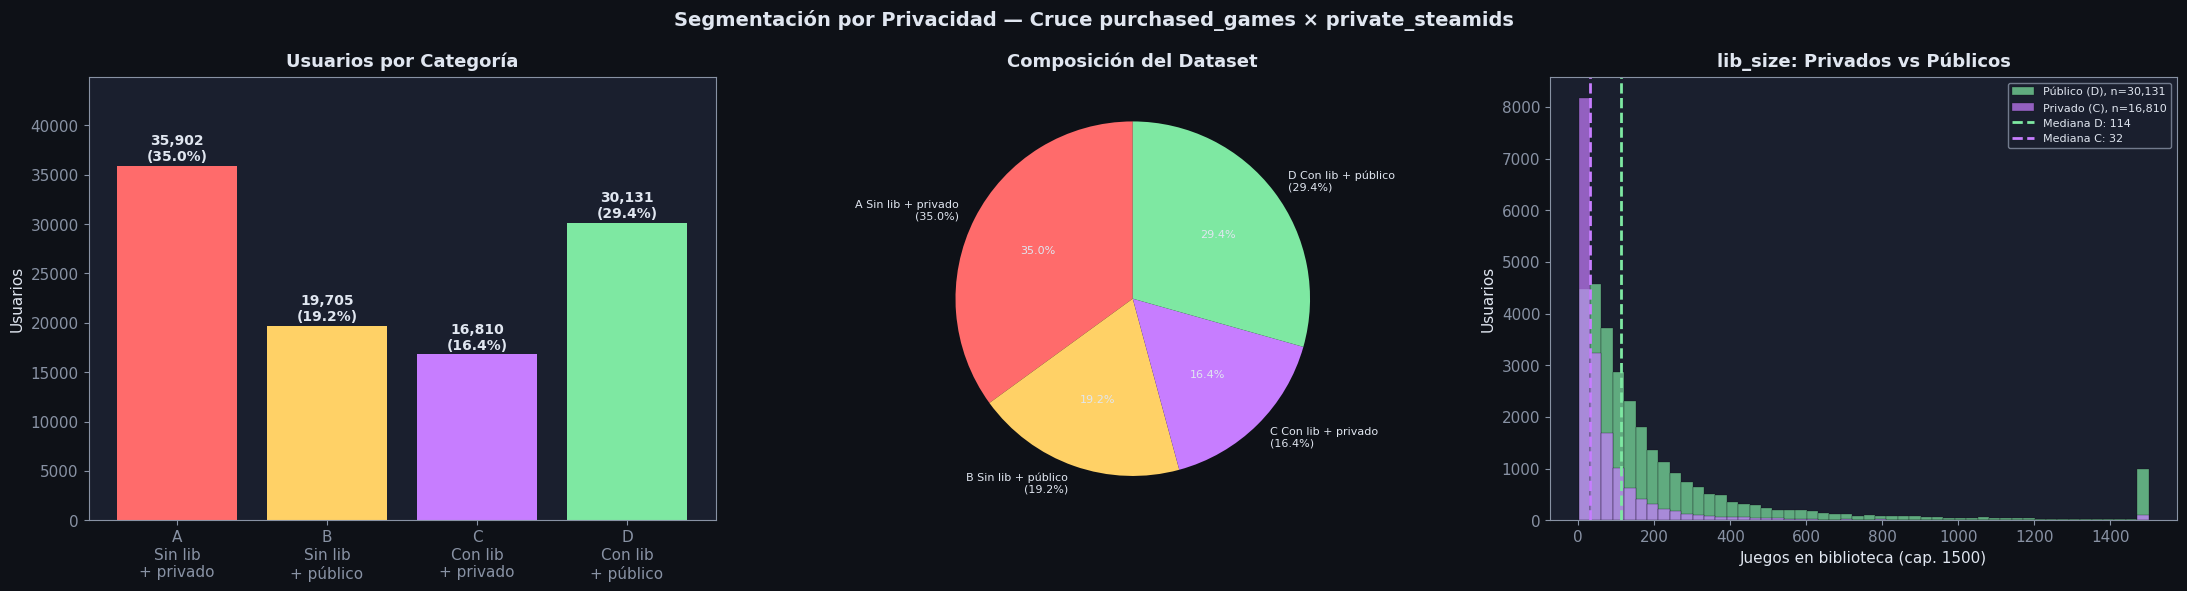

In [25]:
fig, axes = plt.subplots(1, 3, figsize=(22, 6))
fig.patch.set_facecolor(DARK_BG)
fig.suptitle('Segmentación por Privacidad — Cruce purchased_games × private_steamids',
             fontsize=14, fontweight='bold', color=TEXT)

cat_labels  = ['A\nSin lib\n+ privado', 'B\nSin lib\n+ público',
               'C\nCon lib\n+ privado', 'D\nCon lib\n+ público']
cat_sizes   = [len(cat_a), len(cat_b), len(cat_c), len(cat_d)]
cat_colors  = [ACCENT3, ACCENT4, ACCENT5, ACCENT2]


ax = axes[0]
bars = ax.bar(cat_labels, cat_sizes, color=cat_colors)
for bar, val in zip(bars, cat_sizes):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + total*0.005,
            f'{val:,}\n({val/total*100:.1f}%)', ha='center', fontsize=10,
            color=TEXT, fontweight='bold')
ax.set_ylabel('Usuarios'); ax.set_ylim(0, max(cat_sizes)*1.25)
title_ax(ax, 'Usuarios por Categoría')


ax = axes[1]
ax.pie(cat_sizes,
       labels=[f'{l.replace(chr(10), " ")}\n({s/total*100:.1f}%)'
               for l, s in zip(cat_labels, cat_sizes)],
       colors=cat_colors, startangle=90,
       textprops={'color': TEXT, 'fontsize': 8}, autopct='%1.1f%%')
title_ax(ax, 'Composición del Dataset')


ax = axes[2]
cap = 1500
ax.hist(df_d['lib_size'].clip(upper=cap), bins=50, color=ACCENT2, alpha=0.7,
        edgecolor=DARK_BG, linewidth=0.3, label=f'Público (D), n={len(df_d):,}')
ax.hist(df_c['lib_size'].clip(upper=cap), bins=50, color=ACCENT5, alpha=0.7,
        edgecolor=DARK_BG, linewidth=0.3, label=f'Privado (C), n={len(df_c):,}')
ax.axvline(df_d['lib_size'].median(), color=ACCENT2, linewidth=2, linestyle='--',
           label=f'Mediana D: {df_d["lib_size"].median():.0f}')
ax.axvline(df_c['lib_size'].median(), color=ACCENT5, linewidth=2, linestyle='--',
           label=f'Mediana C: {df_c["lib_size"].median():.0f}')
ax.legend(fontsize=8, facecolor=CARD_BG, edgecolor=MUTED, labelcolor=TEXT)
ax.set_xlabel(f'Juegos en biblioteca (cap. {cap})'); ax.set_ylabel('Usuarios')
title_ax(ax, 'lib_size: Privados vs Públicos')

plt.tight_layout()
plt.show()

---
##  Análisis y tratamiento de valores faltantes

### Diagnóstico resuelto

Gracias al cruce con `private_steamids`, los usuarios sin biblioteca observable se descomponen en dos causas principales:

| Causa | n | % del total | Tratamiento |
|---|---|---|---|
| Perfil privado sin datos (Cat. A) | 35,902 | 35.0% | **Etiquetar** `reason='private_no_data'` — no es un error, es un límite de cobertura del dataset |
| Sin juegos genuinamente (Cat. B) | 19,705 | 19.2% | **Etiquetar** `reason='no_games'` — excluir de análisis de biblioteca |

En total, 54.2% de los usuarios no tienen biblioteca observable en el dataset.  
De ellos, la mayoría corresponde a perfiles privados (35.0%), mientras que 19.2% parecen ser cuentas públicas sin juegos registrados.



In [26]:
n_total       = total
n_with_lib    = len(df)
n_private_nd  = len(cat_a)   
n_no_games    = len(cat_b)   

print("Diagnóstico completo de faltantes:")
print(f"  Con library (C + D)                 : {n_with_lib:,}  ({n_with_lib/n_total*100:.1f}%)")
print(f"  Sin library — perfil privado (A)     : {n_private_nd:,}  ({n_private_nd/n_total*100:.1f}%)")
print(f"  Sin library — sin juegos reales (B)  : {n_no_games:,}  ({n_no_games/n_total*100:.1f}%)")
print()

rows_all = []
for r in cat_c:
    rows_all.append({'playerid': r['playerid'], 'lib_size': r['lib_size'],
                     'has_library': True, 'is_private': True,  'reason': 'ok_private'})
for r in cat_d:
    rows_all.append({'playerid': r['playerid'], 'lib_size': r['lib_size'],
                     'has_library': True, 'is_private': False, 'reason': 'ok_public'})
for pid in cat_a:
    rows_all.append({'playerid': pid, 'lib_size': 0,
                     'has_library': False, 'is_private': True,  'reason': 'private_no_data'})
for pid in cat_b:
    rows_all.append({'playerid': pid, 'lib_size': 0,
                     'has_library': False, 'is_private': False, 'reason': 'no_games'})

df_all = pd.DataFrame(rows_all)
print("Distribución de 'reason':")
print(df_all['reason'].value_counts())
print()
print("→ Para ML: usar df (solo has_library=True) con flag is_private.")
print("→ Los 'no_games' son cuentas sin actividad — excluir de features de usuario.")

Diagnóstico completo de faltantes:
  Con library (C + D)                 : 46,941  (45.8%)
  Sin library — perfil privado (A)     : 35,902  (35.0%)
  Sin library — sin juegos reales (B)  : 19,705  (19.2%)

Distribución de 'reason':
reason
private_no_data    35902
ok_public          30131
no_games           19705
ok_private         16810
Name: count, dtype: int64

→ Para ML: usar df (solo has_library=True) con flag is_private.
→ Los 'no_games' son cuentas sin actividad — excluir de features de usuario.


---
##  Distribución del Tamaño de Biblioteca

###  Hallazgos
- La distribución del tamaño de biblioteca es **fuertemente sesgada a la derecha**: mediana 76 juegos, media 240, y un máximo de 32,463 juegos.
- La mayoría de los usuarios tiene bibliotecas relativamente pequeñas: el 75% posee 186 juegos o menos, mientras que el 90% tiene menos de 427 juegos.
- Usando el criterio **IQR (Q3 + 1.5×IQR = 423 juegos)** se identifican 4,736 usuarios outliers (10.1%), correspondientes a bibliotecas significativamente más grandes que la mayoría.
- Un usuario extremo posee 32,463 juegos, más de 10× el percentil 99, lo que sugiere un caso atípico como coleccionista extremo o cuenta asociada a distribución/curaduría.


In [27]:
print("Estadísticas globales de lib_size:")
print(df['lib_size'].describe(percentiles=[.1, .25, .5, .75, .90, .95, .99]))
print()

Q1  = df['lib_size'].quantile(0.25)
Q3  = df['lib_size'].quantile(0.75)
IQR = Q3 - Q1
upper_iqr = Q3 + 1.5 * IQR
p99 = df['lib_size'].quantile(0.99)

print(f"Q1={Q1:.0f}  Q3={Q3:.0f}  IQR={IQR:.0f}")
print(f"Umbral IQR (Q3 + 1.5×IQR) : {upper_iqr:.0f} juegos")
print(f"Percentil 99               : {p99:.0f} juegos")
print(f"Outliers IQR               : {(df['lib_size'] > upper_iqr).sum():,}  ({(df['lib_size'] > upper_iqr).mean()*100:.1f}%)")

Estadísticas globales de lib_size:
count    46941.000000
mean       239.848214
std        869.771849
min          1.000000
10%         10.000000
25%         28.000000
50%         76.000000
75%        186.000000
90%        427.000000
95%        761.000000
99%       3137.600000
max      32463.000000
Name: lib_size, dtype: float64

Q1=28  Q3=186  IQR=158
Umbral IQR (Q3 + 1.5×IQR) : 423 juegos
Percentil 99               : 3138 juegos
Outliers IQR               : 4,736  (10.1%)


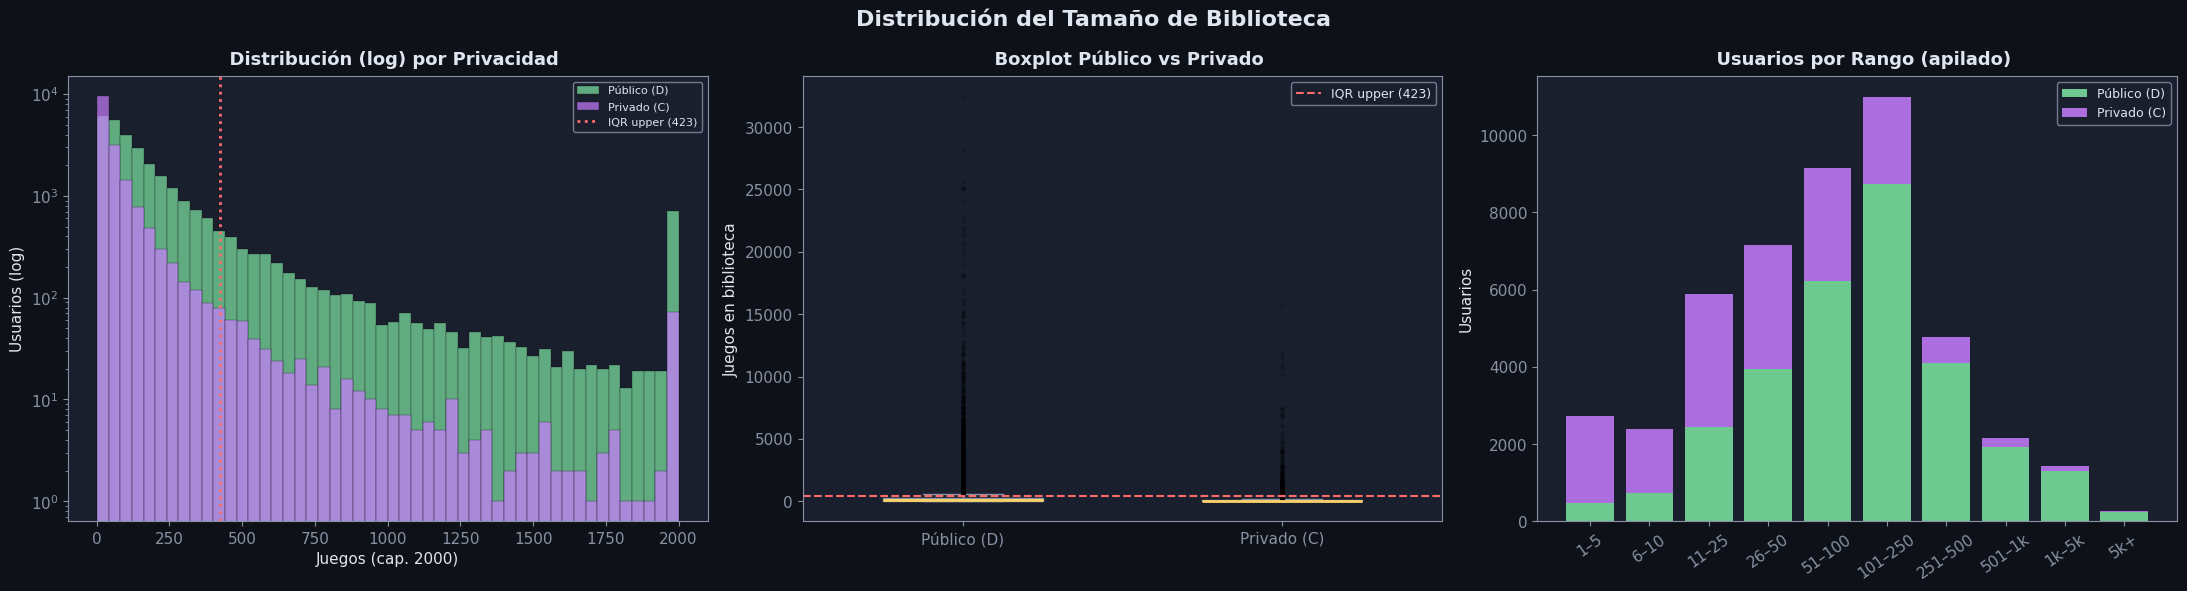

In [28]:
fig, axes = plt.subplots(1, 3, figsize=(22, 6))
fig.patch.set_facecolor(DARK_BG)
fig.suptitle('Distribución del Tamaño de Biblioteca', fontsize=16, fontweight='bold', color=TEXT)

ax = axes[0]
cap = 2000
ax.hist(df[df['is_private']==False]['lib_size'].clip(upper=cap), bins=50,
        color=ACCENT2, alpha=0.7, edgecolor=DARK_BG, linewidth=0.3, label='Público (D)', log=True)
ax.hist(df[df['is_private']==True]['lib_size'].clip(upper=cap),  bins=50,
        color=ACCENT5, alpha=0.7, edgecolor=DARK_BG, linewidth=0.3, label='Privado (C)', log=True)
ax.axvline(upper_iqr, color=ACCENT3, linewidth=2, linestyle=':',
           label=f'IQR upper ({upper_iqr:.0f})')
ax.legend(fontsize=8, facecolor=CARD_BG, edgecolor=MUTED, labelcolor=TEXT)
ax.set_xlabel(f'Juegos (cap. {cap})'); ax.set_ylabel('Usuarios (log)')
title_ax(ax, '  Distribución (log) por Privacidad')

ax = axes[1]
data_box = [df[df['is_private']==False]['lib_size'].values,
            df[df['is_private']==True]['lib_size'].values]
bp = ax.boxplot(data_box, vert=True, patch_artist=True, widths=0.5,
                boxprops=dict(color=MUTED),
                medianprops=dict(color=ACCENT4, linewidth=2),
                whiskerprops=dict(color=MUTED), capprops=dict(color=MUTED),
                flierprops=dict(marker='o', alpha=0.2, markersize=2))
bp['boxes'][0].set_facecolor(ACCENT2)
bp['boxes'][1].set_facecolor(ACCENT5)
ax.set_xticklabels(['Público (D)', 'Privado (C)'])
ax.axhline(upper_iqr, color=ACCENT3, linewidth=1.5, linestyle='--',
           label=f'IQR upper ({upper_iqr:.0f})')
ax.legend(fontsize=9, facecolor=CARD_BG, edgecolor=MUTED, labelcolor=TEXT)
ax.set_ylabel('Juegos en biblioteca')
title_ax(ax, '  Boxplot Público vs Privado')

ax = axes[2]
bins_r   = [0, 5, 10, 25, 50, 100, 250, 500, 1000, 5000, 99999]
labels_r = ['1–5','6–10','11–25','26–50','51–100','101–250','251–500','501–1k','1k–5k','5k+']
df['lib_bucket'] = pd.cut(df['lib_size'], bins=bins_r, labels=labels_r)

pub_counts  = df[df['is_private']==False]['lib_bucket'].value_counts().sort_index().reindex(labels_r, fill_value=0)
priv_counts = df[df['is_private']==True ]['lib_bucket'].value_counts().sort_index().reindex(labels_r, fill_value=0)
x = range(len(labels_r))
ax.bar(x, pub_counts.values,  color=ACCENT2, label='Público (D)', alpha=0.85)
ax.bar(x, priv_counts.values, color=ACCENT5, label='Privado (C)', alpha=0.85,
       bottom=pub_counts.values)
ax.set_xticks(list(x)); ax.set_xticklabels(labels_r, rotation=35)
ax.set_ylabel('Usuarios')
ax.legend(fontsize=9, facecolor=CARD_BG, edgecolor=MUTED, labelcolor=TEXT)
title_ax(ax, '  Usuarios por Rango (apilado)')

plt.tight_layout()
plt.show()

---
##  Outliers: Bibliotecas Extremas y Segmentación

###  Hallazgos

- Usando el umbral IQR (lib_size > 423 juegos) se identifican 4,736 usuarios outliers (10.1%), correspondientes a bibliotecas extremadamente grandes.

- La distribución por tipo de usuario muestra diferencias claras entre perfiles públicos y privados:
  - Públicos (D): 40.1% activos, 45.9% casuales, 13.9% coleccionistas.
  - Privados (C): 16.6% activos, 80.2% casuales, 3.2% coleccionistas.

- Esto confirma que los usuarios privados son mayoritariamente casuales, mientras que los coleccionistas se concentran principalmente en perfiles públicos.

- Aunque los coleccionistas representan una minoría de usuarios, generan una gran parte de la actividad del dataset:
  - 63.8% de los pares (usuario × juego) provienen de coleccionistas.
  - 26.8% de usuarios activos.
  - 9.5% de usuarios casuales.



In [29]:
def user_type(n, upper=upper_iqr):
    if n <= 100:    return 'casual'
    elif n <= upper: return 'activo'
    else:            return 'coleccionista'

df['user_type'] = df['lib_size'].map(user_type)

print("user_type por grupo de privacidad:")
pivot = df.groupby(['is_private', 'user_type']).size().unstack(fill_value=0)
pivot.index = ['Público (D)', 'Privado (C)']
pivot_pct = pivot.div(pivot.sum(axis=1), axis=0) * 100
display(pivot)
print()
print("Porcentajes por fila:")
display(pivot_pct.round(1))
print()

pairs_by_type = {'casual': 0, 'activo': 0, 'coleccionista': 0}
for r in cat_c + cat_d:
    utype = user_type(r['lib_size'])
    pairs_by_type[utype] += r['lib_size']
total_pairs = sum(pairs_by_type.values())
print("Pares (usuario×juego) por user_type:")
for t, n in pairs_by_type.items():
    print(f"  {t:<18}: {n:,}  ({n/total_pairs*100:.1f}% del volumen total)")

user_type por grupo de privacidad:


user_type,activo,casual,coleccionista
Público (D),12096,13844,4191
Privado (C),2789,13476,545



Porcentajes por fila:


user_type,activo,casual,coleccionista
Público (D),40.1,45.9,13.9
Privado (C),16.6,80.2,3.2



Pares (usuario×juego) por user_type:
  casual            : 1,066,280  (9.5% del volumen total)
  activo            : 3,012,412  (26.8% del volumen total)
  coleccionista     : 7,180,023  (63.8% del volumen total)


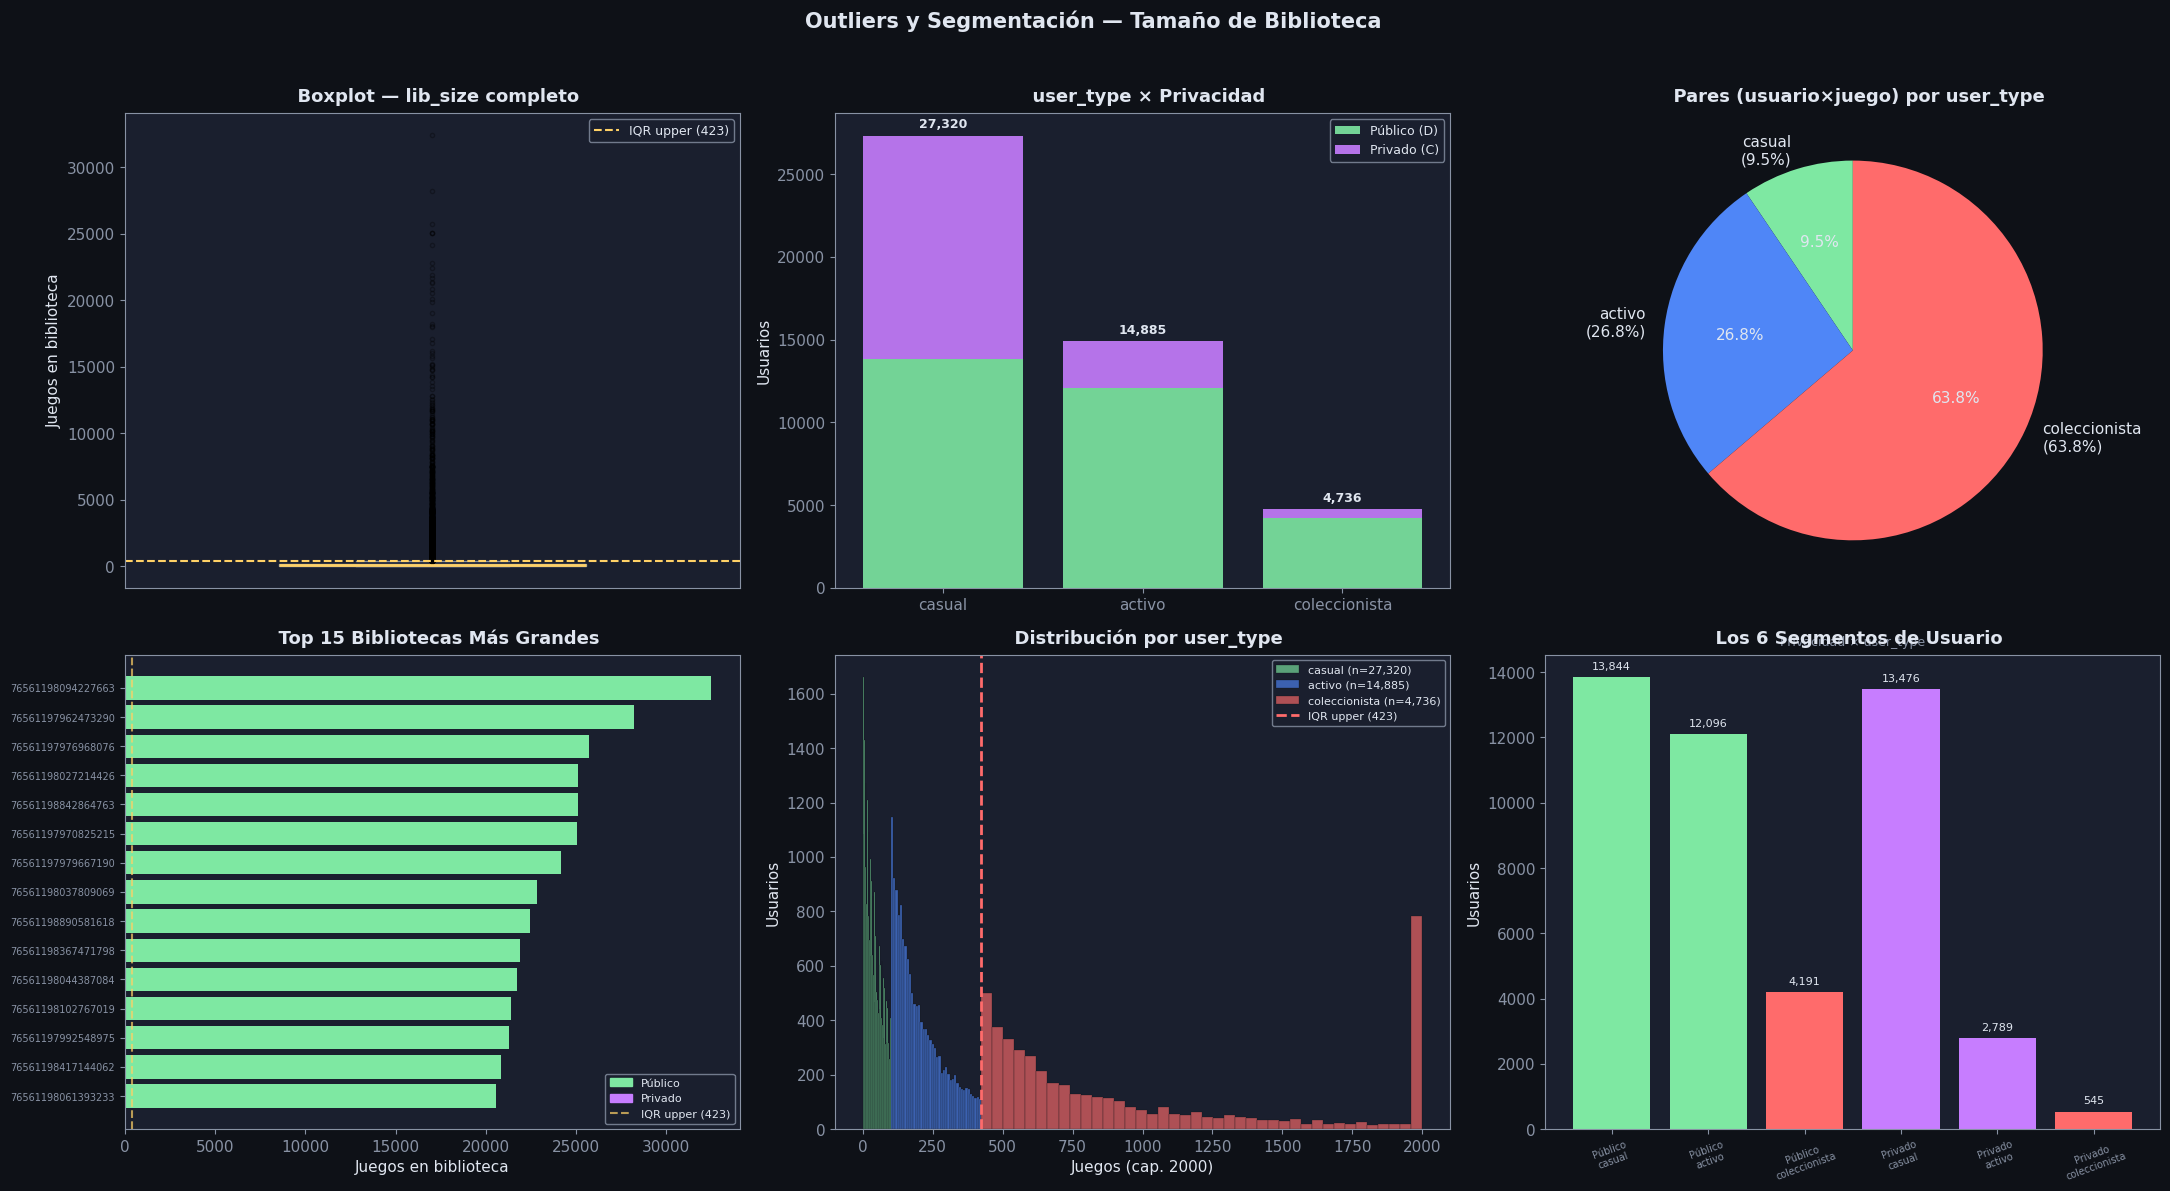

In [30]:
fig, axes = plt.subplots(2, 3, figsize=(22, 12))
fig.patch.set_facecolor(DARK_BG)
fig.suptitle('Outliers y Segmentación — Tamaño de Biblioteca', fontsize=15,
             fontweight='bold', color=TEXT, y=0.99)

type_order  = ['casual', 'activo', 'coleccionista']
type_colors = [ACCENT2, ACCENT1, ACCENT3]

ax = axes[0, 0]
bp = ax.boxplot(df['lib_size'].values, vert=True, patch_artist=True, widths=0.5,
                boxprops=dict(facecolor=ACCENT1, color=MUTED),
                medianprops=dict(color=ACCENT4, linewidth=2),
                whiskerprops=dict(color=MUTED), capprops=dict(color=MUTED),
                flierprops=dict(marker='o', color=ACCENT3, alpha=0.3, markersize=3))
ax.axhline(upper_iqr, color=ACCENT4, linewidth=1.5, linestyle='--',
           label=f'IQR upper ({upper_iqr:.0f})')
ax.legend(fontsize=9, facecolor=CARD_BG, edgecolor=MUTED, labelcolor=TEXT)
ax.set_ylabel('Juegos en biblioteca'); ax.set_xticks([])
title_ax(ax, '  Boxplot — lib_size completo')

ax = axes[0, 1]
pub_t  = [df[(df['is_private']==False) & (df['user_type']==t)].shape[0] for t in type_order]
priv_t = [df[(df['is_private']==True ) & (df['user_type']==t)].shape[0] for t in type_order]
x = range(len(type_order))
b1 = ax.bar(x, pub_t,  color=ACCENT2, label='Público (D)', alpha=0.9)
b2 = ax.bar(x, priv_t, color=ACCENT5, label='Privado (C)', alpha=0.9, bottom=pub_t)
for i, (pv, prv) in enumerate(zip(pub_t, priv_t)):
    total_bar = pv + prv
    ax.text(i, total_bar + len(df)*0.01,
            f'{total_bar:,}', ha='center', fontsize=9, color=TEXT, fontweight='bold')
ax.set_xticks(list(x)); ax.set_xticklabels(type_order)
ax.set_ylabel('Usuarios')
ax.legend(fontsize=9, facecolor=CARD_BG, edgecolor=MUTED, labelcolor=TEXT)
title_ax(ax, '  user_type × Privacidad')

ax = axes[0, 2]
pairs_vals = [pairs_by_type[t] for t in type_order]
ax.pie(pairs_vals,
       labels=[f'{t}\n({v/total_pairs*100:.1f}%)' for t, v in zip(type_order, pairs_vals)],
       colors=type_colors, startangle=90,
       textprops={'color': TEXT}, autopct='%1.1f%%')
title_ax(ax, '  Pares (usuario×juego) por user_type')

ax = axes[1, 0]
top15 = df.nlargest(15, 'lib_size')
colors_top = [ACCENT5 if priv else ACCENT2 for priv in top15['is_private'].values]
ax.barh(top15['playerid'].astype(str)[::-1], top15['lib_size'].values[::-1],
        color=colors_top[::-1])
ax.axvline(upper_iqr, color=ACCENT4, linewidth=1.5, linestyle='--', alpha=0.7,
           label=f'IQR upper ({upper_iqr:.0f})')
ax.legend(fontsize=8, facecolor=CARD_BG, edgecolor=MUTED, labelcolor=TEXT)
ax.tick_params(axis='y', labelsize=7); ax.set_xlabel('Juegos en biblioteca')
legend_els = [mpatches.Patch(color=ACCENT2, label='Público'), mpatches.Patch(color=ACCENT5, label='Privado')]
ax.legend(handles=legend_els + ax.get_legend_handles_labels()[0],
          fontsize=8, facecolor=CARD_BG, edgecolor=MUTED, labelcolor=TEXT)
title_ax(ax, '  Top 15 Bibliotecas Más Grandes')

ax = axes[1, 1]
for t, c in zip(type_order, type_colors):
    subset = df[df['user_type'] == t]['lib_size']
    if len(subset) > 0:
        ax.hist(subset.clip(upper=2000), bins=40, alpha=0.65, color=c,
                edgecolor=DARK_BG, linewidth=0.3, label=f'{t} (n={len(subset):,})')
ax.axvline(upper_iqr, color=ACCENT3, linewidth=2, linestyle='--',
           label=f'IQR upper ({upper_iqr:.0f})')
ax.legend(fontsize=8, facecolor=CARD_BG, edgecolor=MUTED, labelcolor=TEXT)
ax.set_xlabel('Juegos (cap. 2000)'); ax.set_ylabel('Usuarios')
title_ax(ax, '  Distribución por user_type')

ax = axes[1, 2]
seg_labels, seg_vals, seg_cols = [], [], []
for priv, label_priv, col_priv in [(False, 'Público', ACCENT2), (True, 'Privado', ACCENT5)]:
    for t, col_t in zip(type_order, type_colors):
        n = df[(df['is_private']==priv) & (df['user_type']==t)].shape[0]
        seg_labels.append(f'{label_priv}\n{t}')
        seg_vals.append(n)
      
        seg_cols.append(col_priv if t != 'coleccionista' else ACCENT3)

bars_seg = ax.bar(range(len(seg_labels)), seg_vals, color=seg_cols)
for bar, val in zip(bars_seg, seg_vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + len(df)*0.005,
            f'{val:,}', ha='center', fontsize=8, color=TEXT)
ax.set_xticks(range(len(seg_labels)))
ax.set_xticklabels(seg_labels, fontsize=7, rotation=20)
ax.set_ylabel('Usuarios')
title_ax(ax, '  Los 6 Segmentos de Usuario', 'Privacidad × user_type')

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

---
##  Popularidad de Juegos — `n_owners` (todos vs solo públicos)

### Hallazgos 

- El juego 730 (Counter-Strike 2) aparece en 93.7% de las bibliotecas del dataset, lo que lo convierte en el título con mayor penetración en la muestra.

- La diferencia entre usar todos los usuarios y solo perfiles públicos es significativa.  
  Por ejemplo, CS2 pasa de 43,967 propietarios a 28,434 al excluir usuarios privados, lo que implica una reducción de aproximadamente 35%.

- Para el modelo de clasificación, calcularemos dos versiones de la popularidad del juego:
  - `n_owners_all` — máxima cobertura, incluye usuarios privados.
  - `n_owners_public` — métrica más limpia basada solo en perfiles públicos.

- La distribución de `n_owners` presenta una cola larga muy pronunciada: aunque existen 40,988 juegos únicos, la mayoría aparece en muy pocas bibliotecas dentro del dataset, mientras que un pequeño grupo de títulos extremadamente populares concentra gran parte de las bibliotecas.



In [31]:
counter_all    = Counter()
counter_public = Counter()
for r in cat_c + cat_d:
    for gid in r['library']:
        counter_all[gid] += 1
for r in cat_d:
    for gid in r['library']:
        counter_public[gid] += 1

df_games = pd.DataFrame(counter_all.most_common(), columns=['gameid', 'n_owners_all'])
df_games['n_owners_public'] = df_games['gameid'].map(counter_public).fillna(0).astype(int)
df_games['private_contribution'] = df_games['n_owners_all'] - df_games['n_owners_public']
df_games['private_pct'] = (df_games['private_contribution'] / df_games['n_owners_all'] * 100).round(1)
df_games['penetration_pct'] = (df_games['n_owners_all'] / len(cat_c + cat_d) * 100).round(2)

print(f"Juegos únicos en el dataset   : {len(df_games):,}")
print(f"Total pares (usuario×juego)   : {sum(counter_all.values()):,}")
print()
print("Top 20 juegos — comparación n_owners_all vs n_owners_public:")
display(df_games.head(20)[['gameid','n_owners_all','n_owners_public','private_pct','penetration_pct']])

Juegos únicos en el dataset   : 40,988
Total pares (usuario×juego)   : 11,258,715

Top 20 juegos — comparación n_owners_all vs n_owners_public:


,gameid,n_owners_all,n_owners_public,private_pct,penetration_pct
0,730,43967,28434,35.3,93.66
1,578080,28356,19690,30.6,60.41
2,550,24727,18766,24.1,52.68
3,218620,23785,18451,22.4,50.67
4,304930,21620,16271,24.7,46.06
5,1172470,21197,15474,27.0,45.16
6,230410,18906,14324,24.2,40.28
7,431960,18573,14162,23.7,39.57
8,271590,17904,13480,24.7,38.14
9,407530,17711,13754,22.3,37.73


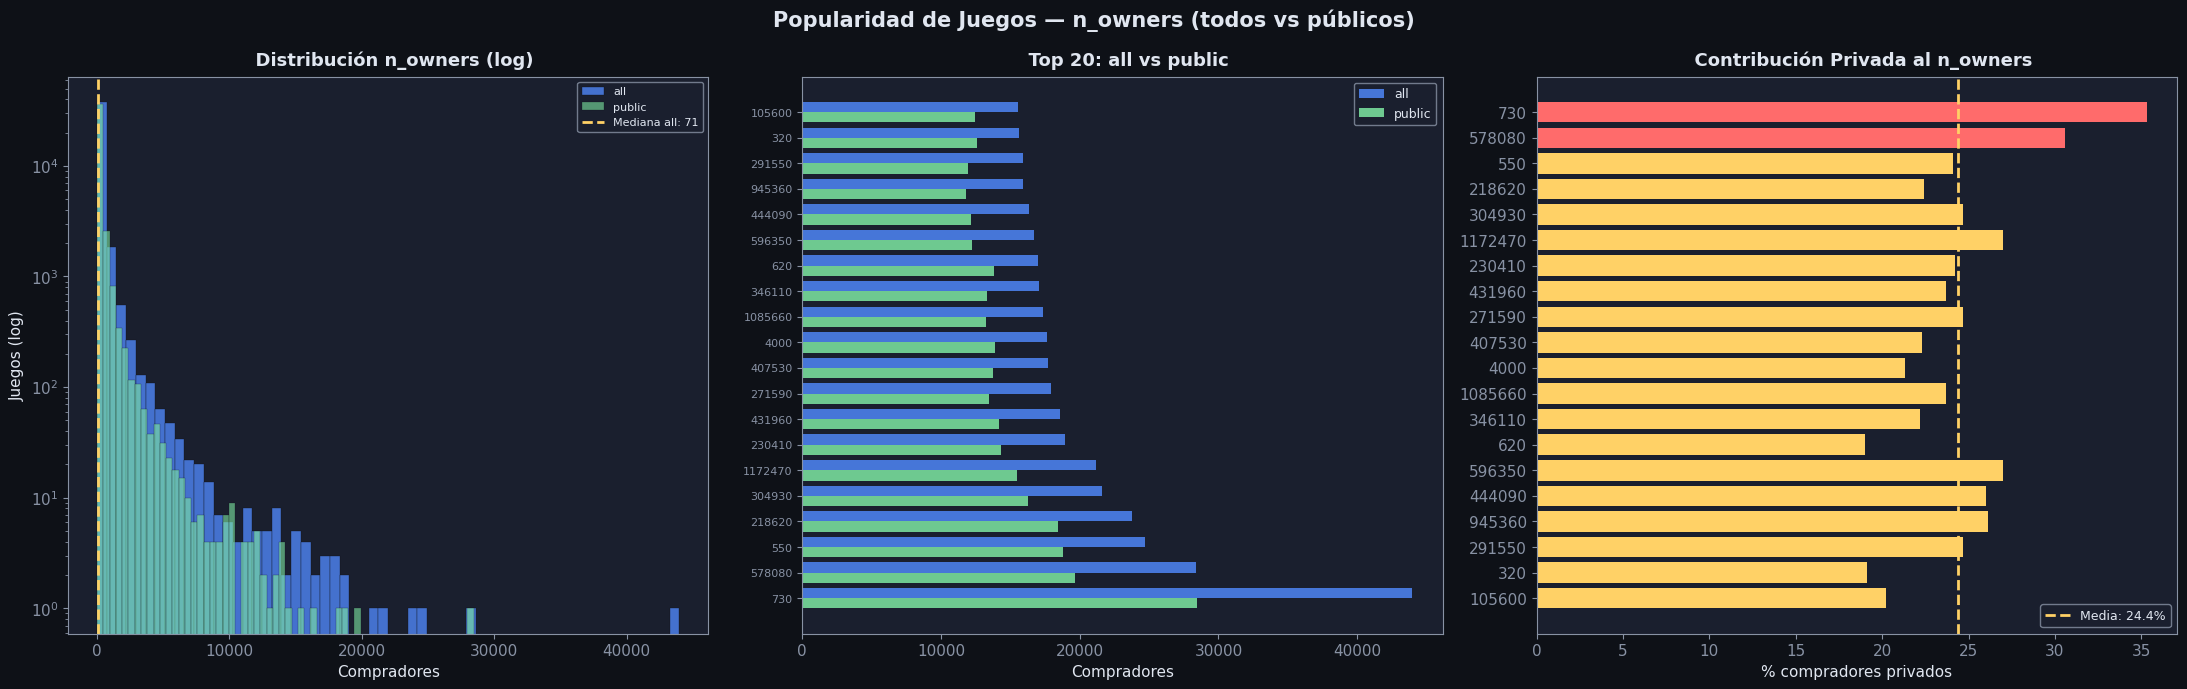

In [32]:
fig, axes = plt.subplots(1, 3, figsize=(22, 7))
fig.patch.set_facecolor(DARK_BG)
fig.suptitle('Popularidad de Juegos — n_owners (todos vs públicos)',
             fontsize=15, fontweight='bold', color=TEXT)

ax = axes[0]
ax.hist(df_games['n_owners_all'], bins=60, color=ACCENT1,
        edgecolor=DARK_BG, linewidth=0.3, log=True, alpha=0.8, label='all')
ax.hist(df_games['n_owners_public'], bins=60, color=ACCENT2,
        edgecolor=DARK_BG, linewidth=0.3, log=True, alpha=0.6, label='public')
ax.axvline(df_games['n_owners_all'].median(), color=ACCENT4, linewidth=2,
           linestyle='--', label=f'Mediana all: {df_games["n_owners_all"].median():.0f}')
ax.legend(fontsize=8, facecolor=CARD_BG, edgecolor=MUTED, labelcolor=TEXT)
ax.set_xlabel('Compradores'); ax.set_ylabel('Juegos (log)')
title_ax(ax, '  Distribución n_owners (log)')

ax = axes[1]
top20 = df_games.head(20)
x = np.arange(len(top20))
w = 0.4
ax.barh(x + w/2, top20['n_owners_all'].values,    height=w, color=ACCENT1, label='all',    alpha=0.85)
ax.barh(x - w/2, top20['n_owners_public'].values, height=w, color=ACCENT2, label='public', alpha=0.85)
ax.set_yticks(x)
ax.set_yticklabels(top20['gameid'].astype(str).tolist(), fontsize=8)
ax.legend(fontsize=9, facecolor=CARD_BG, edgecolor=MUTED, labelcolor=TEXT)
ax.set_xlabel('Compradores')
title_ax(ax, '  Top 20: all vs public')

ax = axes[2]
colors_priv = [ACCENT3 if v > 30 else ACCENT4 if v > 15 else ACCENT2
               for v in top20['private_pct'].values]
ax.barh(top20['gameid'].astype(str)[::-1],
        top20['private_pct'].values[::-1], color=colors_priv[::-1])
ax.axvline(top20['private_pct'].mean(), color=ACCENT4, linewidth=2,
           linestyle='--', label=f'Media: {top20["private_pct"].mean():.1f}%')
ax.legend(fontsize=9, facecolor=CARD_BG, edgecolor=MUTED, labelcolor=TEXT)
ax.set_xlabel('% compradores privados')
title_ax(ax, '  Contribución Privada al n_owners')

plt.tight_layout()
plt.show()

---
##  Dataset limpio final

In [33]:
print("═" * 62)
print("  RESUMEN FINAL — purchased_games × private_steamids")
print("═" * 62)
print(f"  Filas totales en purchased_games : {total:>10,}")
print(f"  IDs en private_steamids (completo): {len(private_set):>9,}")
print()
print(f"  [A] Sin library + privado         : {len(cat_a):>10,}  ({len(cat_a)/total*100:.1f}%)")
print(f"  [B] Sin library + público         : {len(cat_b):>10,}  ({len(cat_b)/total*100:.1f}%)")
print(f"  [C] Con library + privado         : {len(cat_c):>10,}  ({len(cat_c)/total*100:.1f}%)")
print(f"  [D] Con library + público         : {len(cat_d):>10,}  ({len(cat_d)/total*100:.1f}%)")
print()
print(f"  Juegos únicos detectados          : {len(df_games):>10,}")
print(f"  Total pares (usuario×juego)       : {sum(counter_all.values()):>10,}")
print(f"  Outliers IQR lib_size (>815)      : {(df['lib_size'] > upper_iqr).sum():>10,}")
print("═" * 62)
print()
print("Tablas disponibles:")
print("  df       — usuarios con library (lib_size, is_private, user_type)")
print("  df_all   — todos los usuarios (has_library, is_private, reason)")
print("  df_games — juegos con n_owners_all, n_owners_public, private_pct")
print()
df.head(3)

══════════════════════════════════════════════════════════════
  RESUMEN FINAL — purchased_games × private_steamids
══════════════════════════════════════════════════════════════
  Filas totales en purchased_games :    102,548
  IDs en private_steamids (completo):   227,963

  [A] Sin library + privado         :     35,902  (35.0%)
  [B] Sin library + público         :     19,705  (19.2%)
  [C] Con library + privado         :     16,810  (16.4%)
  [D] Con library + público         :     30,131  (29.4%)

  Juegos únicos detectados          :     40,988
  Total pares (usuario×juego)       : 11,258,715
  Outliers IQR lib_size (>815)      :      4,736
══════════════════════════════════════════════════════════════

Tablas disponibles:
  df       — usuarios con library (lib_size, is_private, user_type)
  df_all   — todos los usuarios (has_library, is_private, reason)
  df_games — juegos con n_owners_all, n_owners_public, private_pct



,playerid,lib_size,is_private,lib_bucket,user_type
0,76561198119605821,20,True,11–25,casual
1,76561197972409418,275,True,251–500,activo
2,76561198068969988,330,True,251–500,activo


---
## Exportar dataset limpio

> Exporta el dataframe limpio con todas las columnas calculadas en este EDA. El notebook `eda_feature_engineering` carga este CSV directamente — no recalcula nada.

**Archivos generados:**
- `purchased_users.csv` — una fila por usuario: `playerid`, `lib_size`, `user_type`, `is_private`, `has_library`
- `purchased_per_game.csv` — una fila por juego: `gameid`, `n_owners_all`, `n_owners_public`, `private_pct`, `penetration_pct`


In [35]:
rows_all_export = []
for r in cat_c + cat_d:
    rows_all_export.append({
        "playerid":    r["playerid"],
        "lib_size":    r["lib_size"],
        "user_type":   user_type(r["lib_size"]),
        "is_private":  r["playerid"] in private_set,
        "has_library": True,
    })
for pid in cat_a:
    rows_all_export.append({"playerid": pid, "lib_size": 0,
                            "user_type": "casual", "is_private": True, "has_library": False})
for pid in cat_b:
    rows_all_export.append({"playerid": pid, "lib_size": 0,
                            "user_type": "casual", "is_private": False, "has_library": False})

df_export = pd.DataFrame(rows_all_export)

df_export.to_csv("Datos/purchased_users.csv", index=False)

# ── purchased_per_game.csv ────────────────────────────────────────────────────
cols_games_exp = ["gameid","n_owners_all","n_owners_public","private_pct","penetration_pct"]
df_games[cols_games_exp].to_csv("Datos/purchased_per_game.csv", index=False)

print(f"purchased_users.csv    : {len(df_export):,} usuarios")
n_with    = df_export['has_library'].sum()
n_without = (~df_export['has_library']).sum()
print(f"  has_library=True     : {n_with:,}")
print(f"  has_library=False    : {n_without:,}")
print(f"purchased_per_game.csv : {len(df_games):,} juegos")
df_export.head(3)


purchased_users.csv    : 102,548 usuarios
  has_library=True     : 46,941
  has_library=False    : 55,607
purchased_per_game.csv : 40,988 juegos


,playerid,lib_size,user_type,is_private,has_library
0,76561198119605821,20,casual,True,True
1,76561197972409418,275,activo,True,True
2,76561198068969988,330,activo,True,True


---
##  Conclusiones


### Próximos pasos
- **Usar `n_owners_public`** como feature principal del modelo de clasificación — más limpia que `n_owners_all`.
- **Usar `user_type` + `is_private`** como features del usuario en el modelo de regresión.
- **Flag F2P — este notebook aporta `n_owners_public`:** cruzar con `has_price=False` de `prices` en el notebook de feature engineering. Lógica: si `n_owners_public > umbral` Y `has_price = False`, entonces `is_f2p = True`.
- **Cruzar con `history`:** ¿los usuarios con más juegos en biblioteca también desbloquean más logros? ¿Correlación `lib_size` ↔ `n_logros_par`?
- **Cruzar con `prices`:** unir `price_tier` y `usd_log` a `df_games` usando `gameid` como clave.
- **Cruzar con `games`:** unir `genre`, `release_date` y flags de spam a `df_games` usando `gameid`.